In [1]:
%load_ext autoreload
%autoreload 2
import os

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore

### Waveform distance schematics — RMSE, nRMSE, Cos Sim
Each shows two cluster-average waveforms and the shaded region representing the metric.

In [3]:
SINGLE_COLOR = 'black'
AVG_COLOR    = '#1A7F5A'
FILL_COLOR   = '#E69F00'


def _synthetic_eap(t, peak_amp, peak_width=0.35, trough_frac=0.28, trough_delay=0.68):
    pre    = -0.13 * peak_amp * np.exp(-((t + 0.38)**2) / (2 * 0.13**2))
    peak   =  peak_amp        * np.exp(-((t       )**2) / (2 * peak_width**2))
    trough = -trough_frac * peak_amp * np.exp(-((t - trough_delay)**2) / (2 * 0.28**2))
    return pre + peak + trough


def _base_waveforms(sigma=2):
    t = np.linspace(-1.0, 1.6, 600)
    wf_avg    = gaussian_filter1d(_synthetic_eap(t, peak_amp=1.00, peak_width=0.30,
                                                 trough_frac=0.28, trough_delay=0.66), sigma=sigma)
    wf_single = gaussian_filter1d(_synthetic_eap(t, peak_amp=0.55, peak_width=0.44,
                                                 trough_frac=0.20, trough_delay=0.72), sigma=sigma)
    return t, wf_avg, wf_single


def _schematic_axes(figsize=(4, 4), lw=9, label_fontsize=22):
    fig, ax = plt.subplots(figsize=figsize)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('black')
        spine.set_visible(True)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    return fig, ax, lw, label_fontsize


def plot_rmse_schematic(figsize=(4, 4), lw=9, label_fontsize=22):
    t, wf_avg, wf_single = _base_waveforms()
    fig, ax, lw, label_fontsize = _schematic_axes(figsize, lw, label_fontsize)
    ax.fill_between(t, wf_single, wf_avg, color=FILL_COLOR, alpha=0.30)
    ax.plot(t, wf_avg,    color=AVG_COLOR,    lw=lw,        solid_capstyle='round')
    ax.plot(t, wf_single, color=SINGLE_COLOR, lw=lw * 0.75, solid_capstyle='round')
    ax.set_xlabel('RMSE', fontsize=label_fontsize, fontweight='bold', labelpad=10,
                  fontfamily='Helvetica Neue')
    plt.tight_layout()
    return fig


def plot_nrmse_schematic(figsize=(4, 4), lw=9, label_fontsize=22):
    t, wf_avg, wf_single = _base_waveforms()
    global_max = max(np.abs(wf_avg).max(), np.abs(wf_single).max())
    n_avg    = wf_avg    / global_max
    n_single = wf_single / global_max
    fig, ax, lw, label_fontsize = _schematic_axes(figsize, lw, label_fontsize)
    ax.fill_between(t, n_single, n_avg, color=FILL_COLOR, alpha=0.30)
    ax.plot(t, n_avg,    color=AVG_COLOR,    lw=lw,        solid_capstyle='round')
    ax.plot(t, n_single, color=SINGLE_COLOR, lw=lw * 0.75, solid_capstyle='round')
    ax.set_xlabel('nRMSE', fontsize=label_fontsize, fontweight='bold', labelpad=10,
                  fontfamily='Helvetica Neue')
    plt.tight_layout()
    return fig


def plot_cossim_schematic(figsize=(4, 4), lw=9, label_fontsize=22):
    t, wf_avg, wf_single = _base_waveforms()
    z_avg    = zscore(wf_avg)
    z_single = zscore(wf_single)
    fig, ax, lw, label_fontsize = _schematic_axes(figsize, lw, label_fontsize)
    ax.fill_between(t, z_single, z_avg, color=FILL_COLOR, alpha=0.30)
    ax.plot(t, z_avg,    color=AVG_COLOR,    lw=lw,        solid_capstyle='round')
    ax.plot(t, z_single, color=SINGLE_COLOR, lw=lw * 0.75, solid_capstyle='round')
    ax.set_xlabel('Cos Sim', fontsize=label_fontsize, fontweight='bold', labelpad=10,
                  fontfamily='Helvetica Neue')
    plt.tight_layout()
    return fig

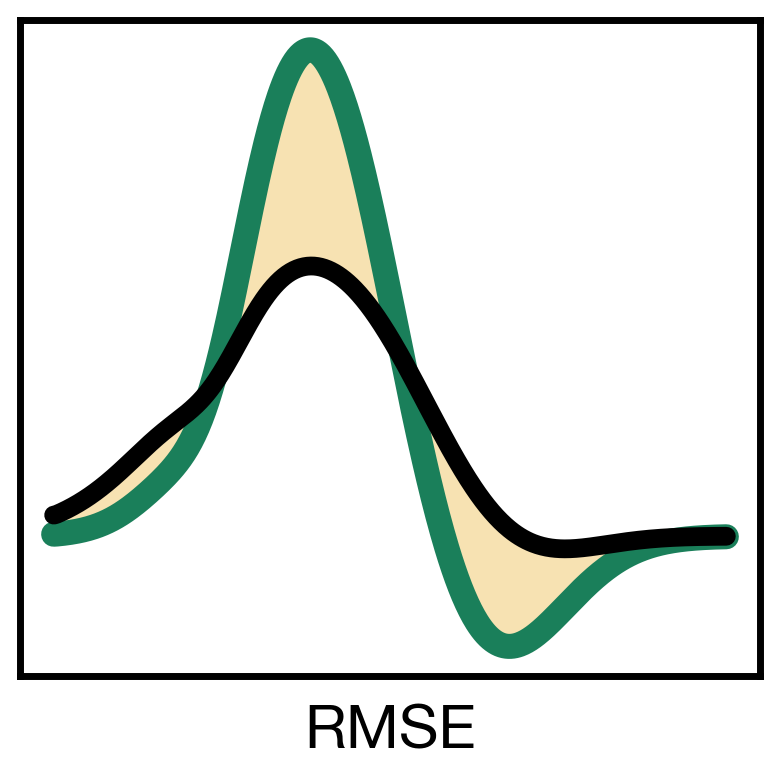

In [4]:
plot_rmse_schematic()
plt.show()

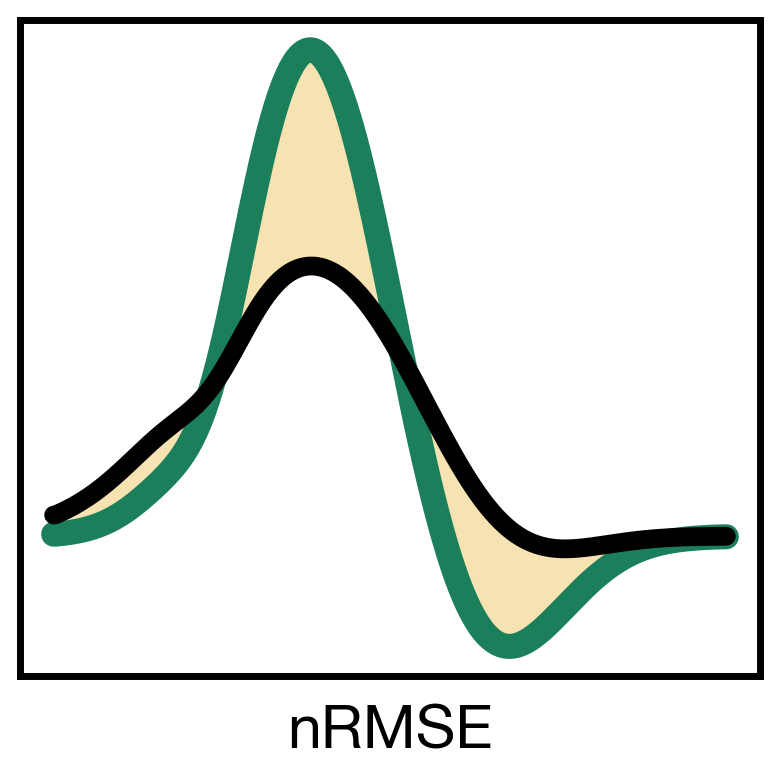

In [5]:
plot_nrmse_schematic()
plt.show()

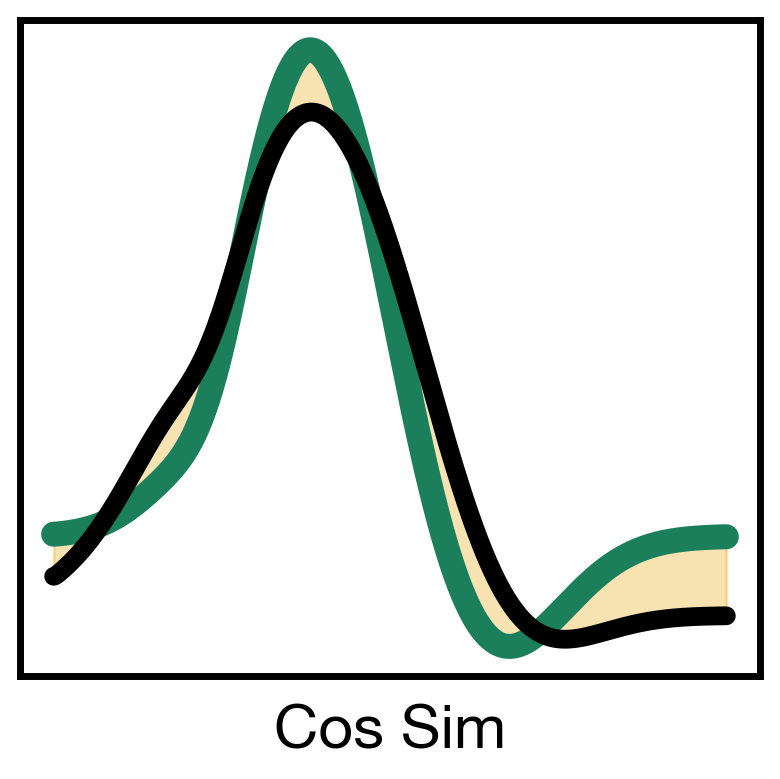

In [6]:
plot_cossim_schematic()
plt.show()